In [1]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import os
import math

#plt.rcParams['text.usetex'] = True
#rfont = {'fontname':'Times New Roman'}
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# Spin matrix
S0 = qt.qeye(3)                                                # {1, 0, -1}
Sx, Sy, Sz = qt.jmat(1)                                        # {1, 0, -1}
sigma0 = qt.qeye(2)                                            # {Ex, Ey}
sigmax, sigmay, sigmaz = qt.sigmax(), qt.sigmay(), qt.sigmaz() # {Ex, Ey}

# Physics constant
h             = 6.626e-34        # J/Hz
muB           = 9.274e-24 / h    # Hz/T
Des_para      = 1.42e9           # Hz       # [Doherty 2013], 1.44e9[Bassett 2014] 
Des_perp      = 1.55e9/2         # Hz       # [Doherty 2013], 1.541e9[Bassett 2014] 
lambdaes_para = 5.3e9            # Hz       # [Doherty 2013], 5.33e9[Bassett 2014]
lambdaes_perp = 0.2e9/np.sqrt(2) # Hz       # [Doherty 2013]
des_para      = 6e3              # Hz/(V/m) # [Doherty 2013]?
des_perp      = 6e3              # Hz/(V/m) # [Doherty 2013]?
les_para      = 0.1              # 1        # [Doherty 2013], 0.05[Bassett 2014] at 1.5K
ges_para      = 2.01             # 1        # [Doherty 2013], 2.15[Bassett 2014]
ges_perp      = 2.01             # 1        # [Doherty 2013]
gamma_E       = muB * ges_para

In [2]:
# Decompostion of eigenstates based on spin basis
def Decomposition(H_tot):
    ee, ev = H_tot.eigenstates()
    ev_amp = [abs(evi.full()) for evi in ev][::-1]

    return ev_amp


# condition value
def Xi(List, i, j):
    a_i = List[i]
    a_j = List[j]

    return ( abs( abs(a_i)-abs(a_j) ) )/(abs(a_i) + abs(a_j) )

def Xi_pro(List, i, j):
    a_i = List[i-1]
    a_j = List[j-1]

    return (abs(a_i))**2 * (abs(a_j))**2

# Ductionary of ES and spin basis
Es = {'|A_2>': 0,'|A_1>': 1,'|E_x>': 2,'|E_y>': 3,'|E_1>': 4,'|E_2>': 5 }
spin_basis = {'|Ex,+1>': 0,'|Ex,0>': 1,'|Ex,-1>': 2,'|Ey,+1>': 3,'|Ey,0>': 4,'|Ey,-1>': 5 }

# extraction fot key 
def get_key_from_value(d, val):
    keys = [k for k, v in d.items() if v == val]
    if keys:
        return keys[0]
    return None

key1 = get_key_from_value(spin_basis, 1)
key1

'|Ex,0>'

In [3]:
# bare Hamiltonian
H_es = Des_para * qt.tensor(sigma0, Sz**2 - 2/3 * S0) \
       - lambdaes_para * qt.tensor(sigmay, Sz) \
       + Des_perp * (qt.tensor(sigmaz, Sy**2 - Sx**2) - qt.tensor(sigmax, Sy * Sx + Sx * Sy)) \
       + lambdaes_perp * (qt.tensor(sigmaz, Sx * Sz + Sz * Sx) - qt.tensor(sigmax, Sy * Sz + Sz * Sy))

# Interaction Hamiltonian
def V_es(E, B, delta):
    return des_para * (E[2] + delta[2]) * qt.tensor(sigma0, S0) \
           + des_perp * (E[0] + delta[0]) * qt.tensor(sigmaz, S0) \
           - des_perp * (E[1] + delta[1]) * qt.tensor(sigmax, S0) \
           + muB * (les_para * qt.tensor(sigmay, S0) + ges_para * qt.tensor(sigma0, Sz)) * B[2] \
           + muB * ges_perp * qt.tensor(sigma0, Sx * B[0] + Sy * B[1])


In [10]:
# Prototype 

# definition of making colormap, spni_basis. Now, we assuume i, j as labeling of spin basis
def making_colormap_spin_basis_Xi(spin_number,i,j,save_path=None):
    # Meshgrid parameters
    E = [0,0,0]
    strain_perp_values = np.linspace(0, 60e9, 100)
    Bz_values = np.linspace(0, 5000e-4, 100)

    # initialization 
    score = 0.0

    # Allocate result matrix
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))
    #highlight_points = []

    # Evaluate Xi over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[spin_number]  # Assuming first eigenstate
            diff = Xi(amp_list, i, j)         # Xi between 1st and 3rd components
            
            if diff < 1e-2:
                diff = 1e-2
                score = abs(1e9 / diff)
         
            score = abs(1e9/diff)
            #score = np.abs(1e9/diff)

            score_map[k,w] = math.log10(score) 
            #score_map[k, w] = score.item() if isinstance(score, np.ndarray) else score



    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map, extent=[   Bz_values[0]*1e3, Bz_values[-1]*1e3,
        strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
            origin='lower', aspect='auto', cmap='viridis')

    # Overlay scatter points
    #highlight_points = np.array(highlight_points)
    #if len(highlight_points) > 0:
        #plt.scatter(highlight_points[:, 0], highlight_points[:, 1],
                    #color='red', s=10, label='|a₀|^2+|a₂|^2 > 0.45')

    # converting spin_number => ES
    E_state = get_key_from_value(Es, spin_number)
    i_component = get_key_from_value(spin_basis, i)
    j_component = get_key_from_value(spin_basis, j)

    plt.colorbar(label=r'$\xi_{%s,%s}$, (i+j)/(i-j)' %(i,j))
    plt.xlabel('Magnetic field Bz (mT)')
    plt.ylabel(r'Strain $\delta_{\perp}$ (GHz)')
    plt.title('Degree of mixture of spin basis (%s vs %s component) in %s' %(i_component,j_component,E_state))
    plt.tight_layout()

     # Save or show the plot
    if save_path:
        filename = f"{save_path}/spin_mixture_{i}_{j}in_{E_state}.png"
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

In [11]:
# Prototype 

# definition of making colormap, spni_basis. Now, we assuume i, j as labeling of spin basis
def making_colormap_spin_basis_Xi_pro(spin_number,i,j,save_path=None):
    # Meshgrid parameters
    E = [0,0,0]
    strain_perp_values = np.linspace(0, 60e9, 100)
    Bz_values = np.linspace(0, 5000e-4, 100)

    # initialization 
    score = 0.0

    # Allocate result matrix
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))
    #highlight_points = []

    # Evaluate Xi over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[spin_number]  # Assuming first eigenstate
            diff = Xi_pro(amp_list, i, j)
            score = diff
            score_map[k, w] = score



    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(score_map, extent=[   Bz_values[0]*1e3, Bz_values[-1]*1e3,
        strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
            origin='lower', aspect='auto', cmap='viridis')

    # Overlay scatter points
    #highlight_points = np.array(highlight_points)
    #if len(highlight_points) > 0:
        #plt.scatter(highlight_points[:, 0], highlight_points[:, 1],
                    #color='red', s=10, label='|a₀|^2+|a₂|^2 > 0.45')

    # converting spin_number => ES
    E_state = get_key_from_value(Es, spin_number)
    i_component = get_key_from_value(spin_basis, i)
    j_component = get_key_from_value(spin_basis, j)

    plt.colorbar(label=r'$\xi_{%s,%s}$, abs(i)^2 * abs(j)^2' %(i,j))
    plt.xlabel('Magnetic field Bz (mT)')
    plt.ylabel(r'Strain $\delta_{\perp}$ (GHz)')
    plt.title('Degree of mixture of spin basis (%s vs %s component) in %s' %(i_component,j_component,E_state))
    plt.tight_layout()

     # Save or show the plot
    if save_path:
        filename = f"{save_path}/spin_mixture_{i}_{j}in_{E_state}.png"
        plt.savefig(filename)
        plt.close()
    else:
        plt.show()

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_29668\1485410964.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


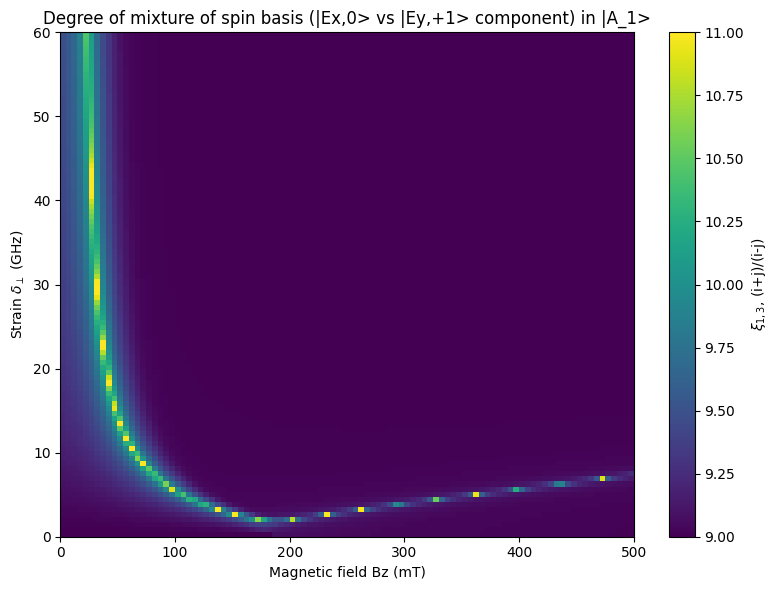

C:\Users\Tsuchiya Saki\AppData\Local\Temp\ipykernel_29668\2785759040.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = score


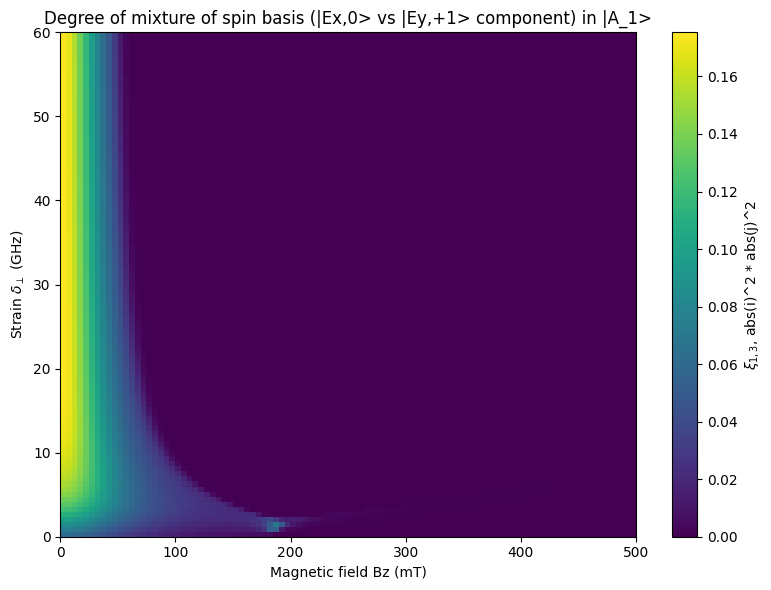

In [12]:
s = 1
making_colormap_spin_basis_Xi(s,1,3)
making_colormap_spin_basis_Xi_pro(s, 1, 3)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\2009029424.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


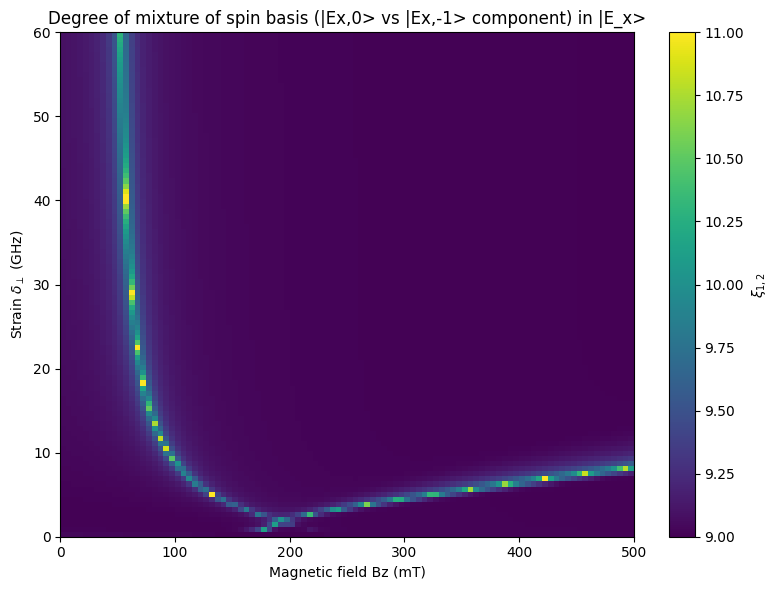

In [46]:
s = 2
making_colormap_spin_basis(s,1,2)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\2009029424.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


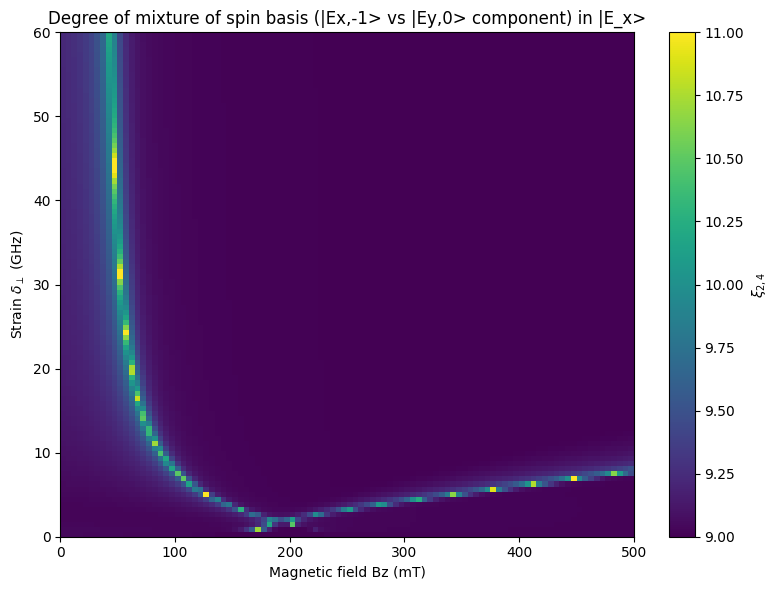

In [47]:
s = 2
making_colormap_spin_basis(s,2,4)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\2009029424.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


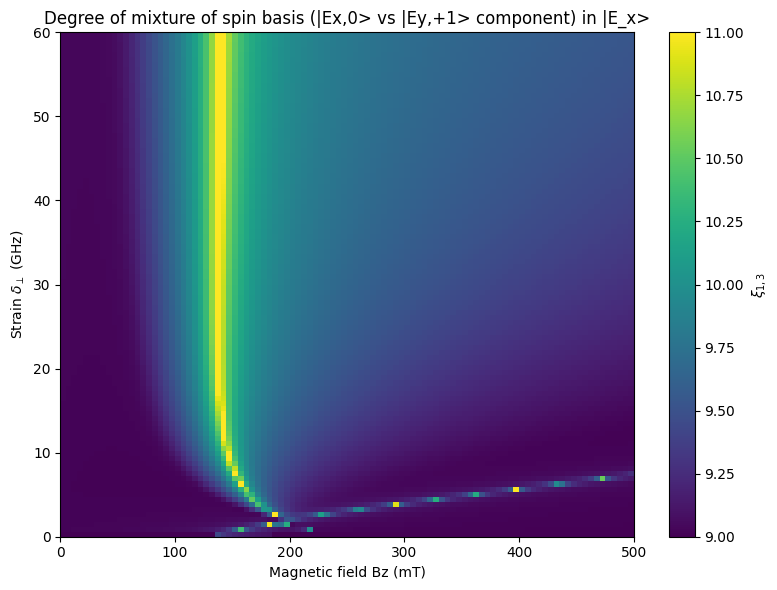

In [51]:
s = 2
making_colormap_spin_basis(s,1,3)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\2009029424.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


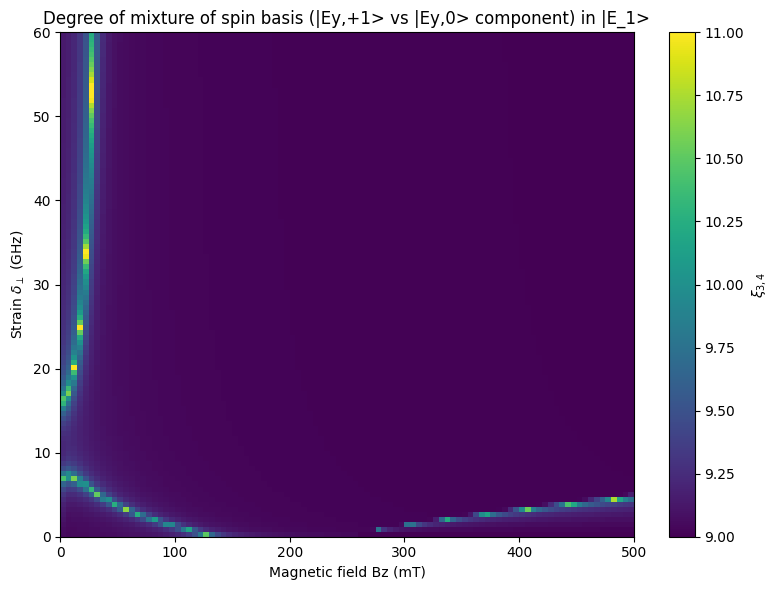

In [48]:
s = 4
making_colormap_spin_basis(s,3,4)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\2009029424.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


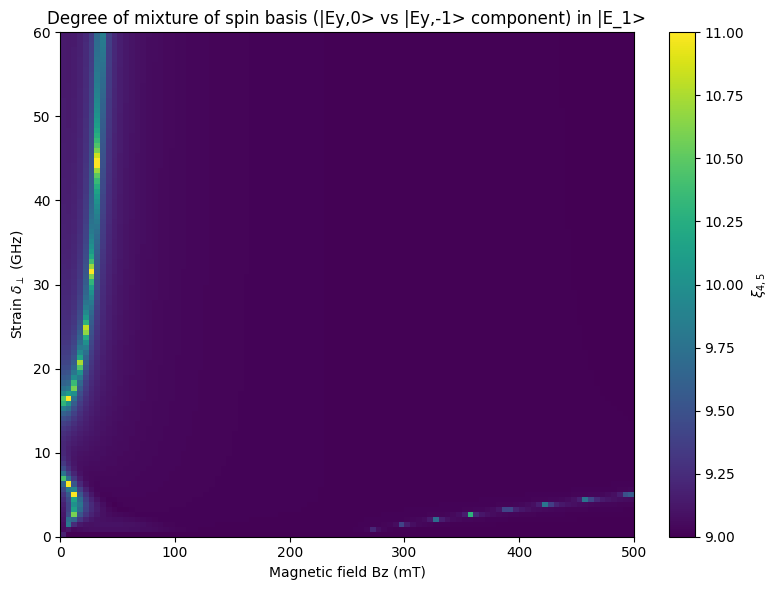

In [50]:
s = 4
making_colormap_spin_basis(s,4,5)

In [ ]:
s = 4
making_colormap_spin_basis(s,3,4)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\3868429595.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k,w] = math.log10(score)


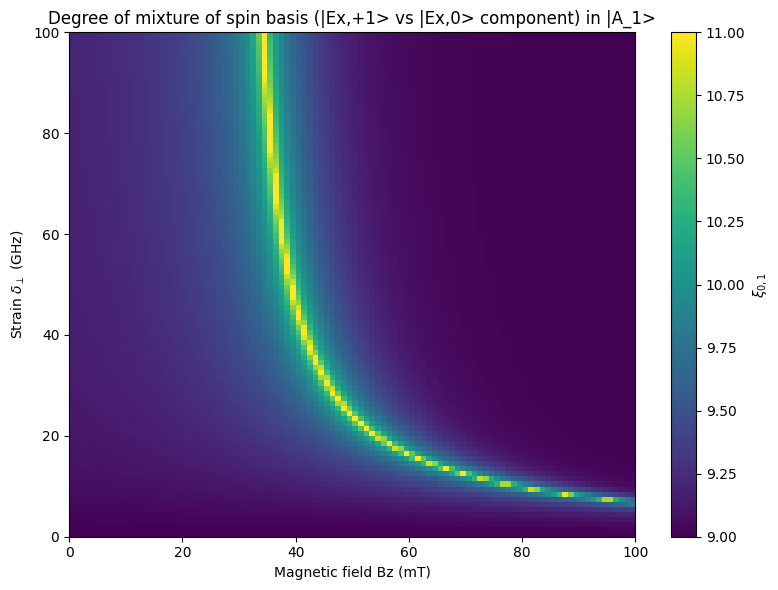

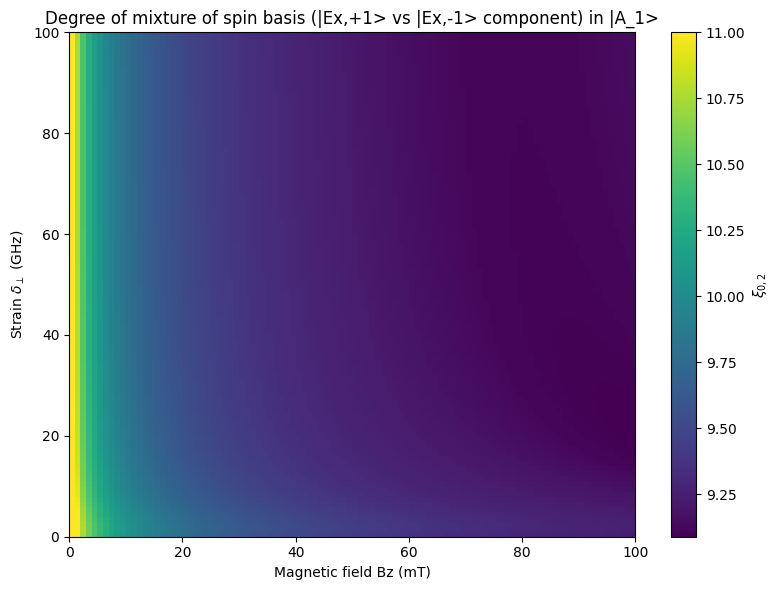

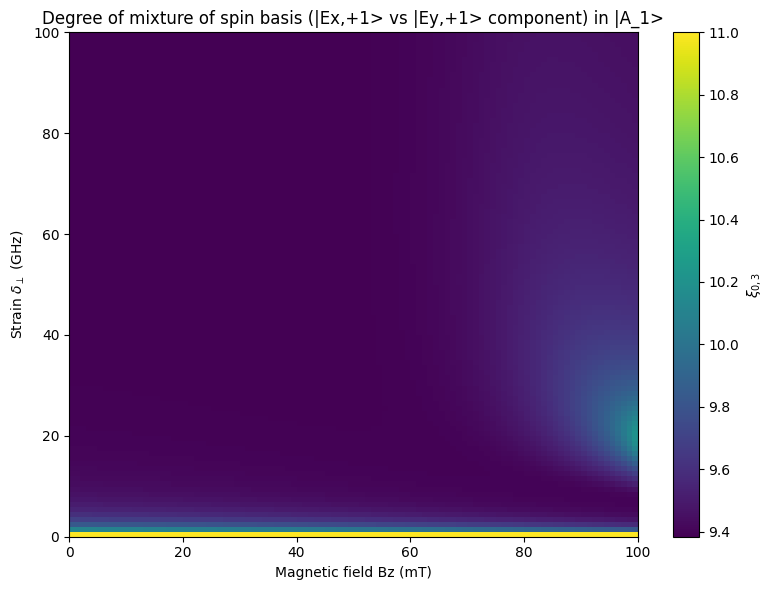

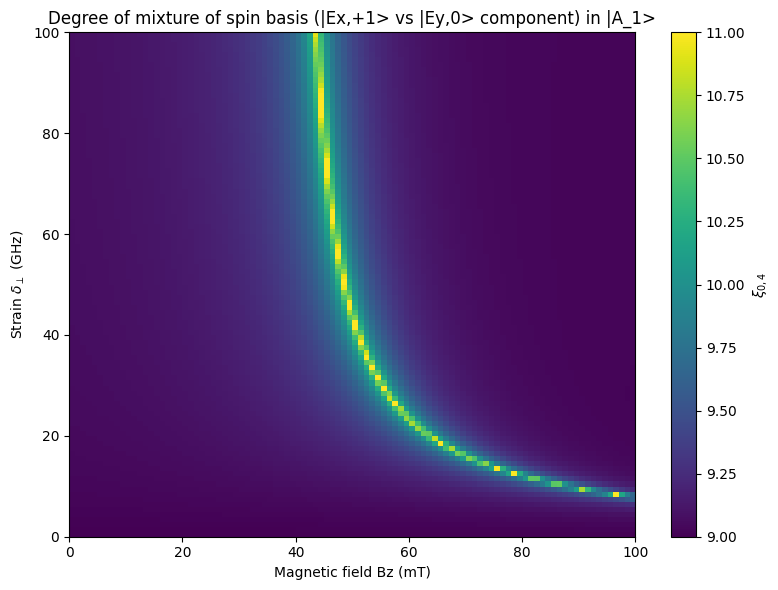

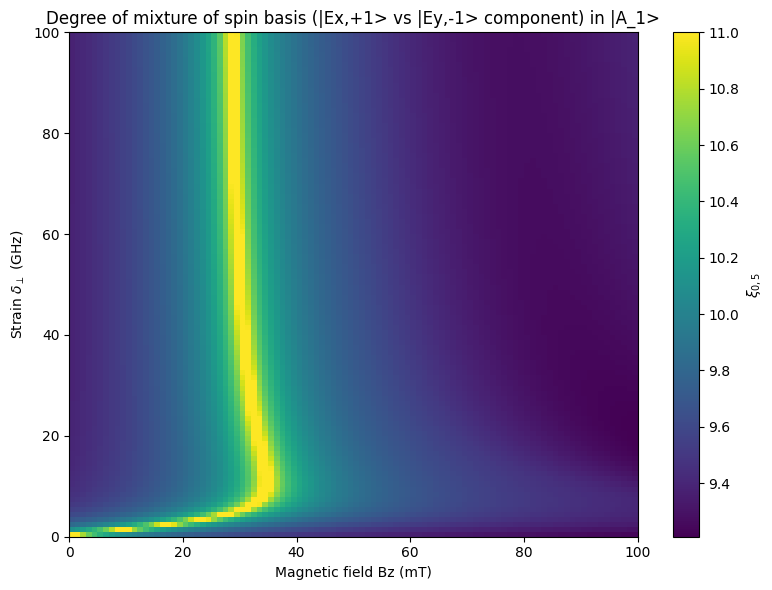

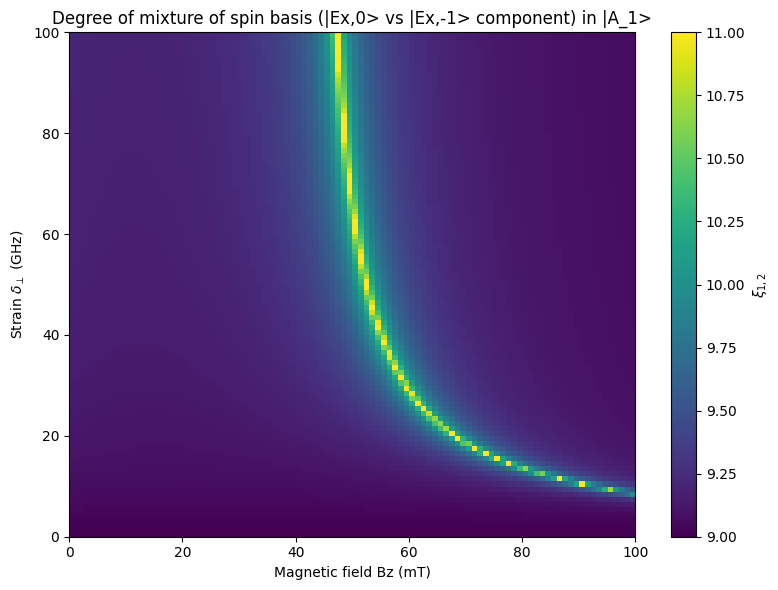

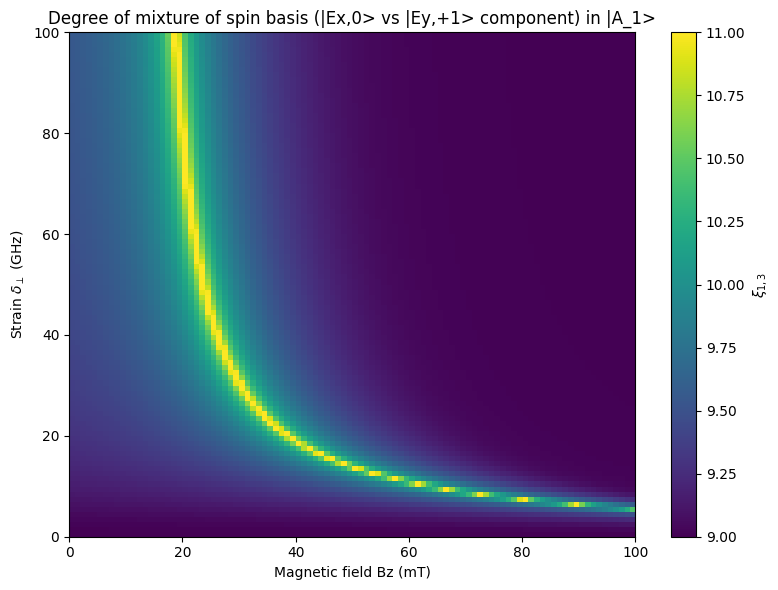

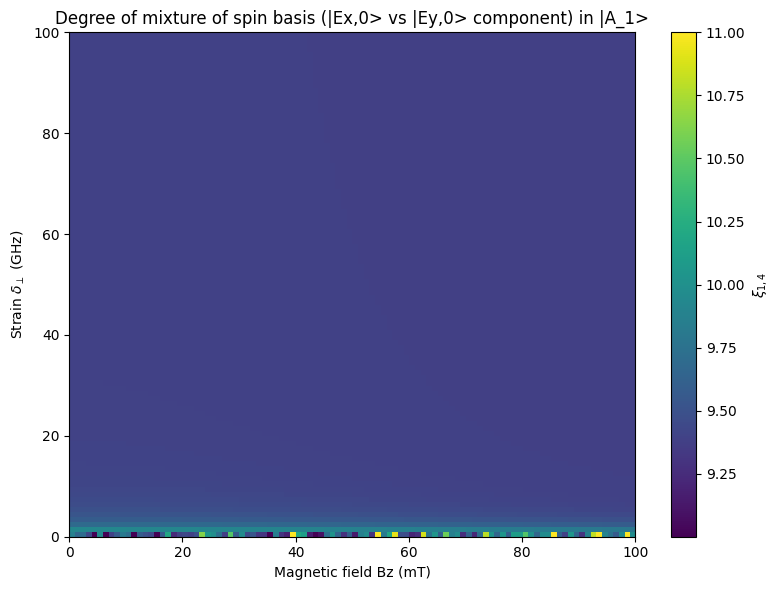

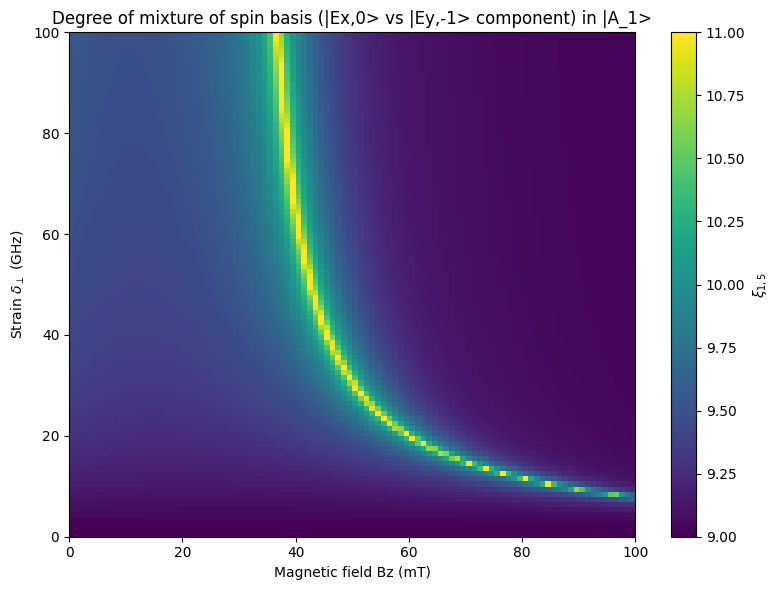

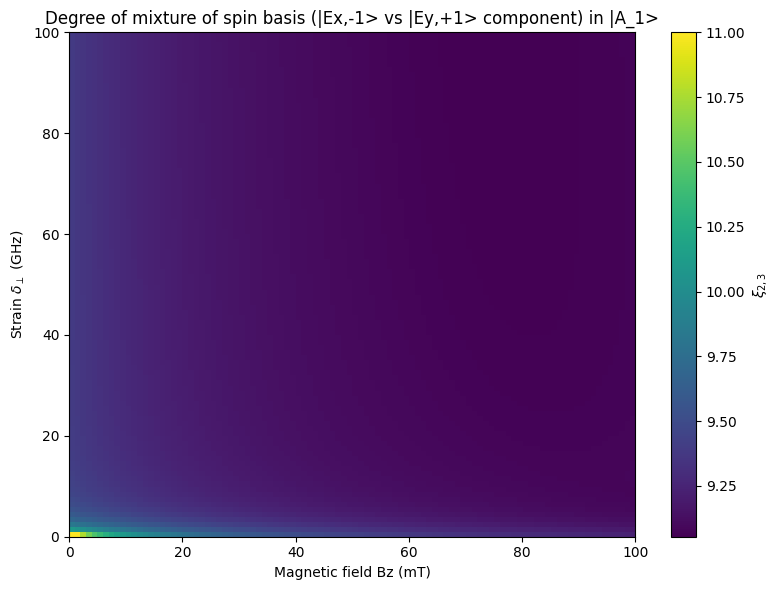

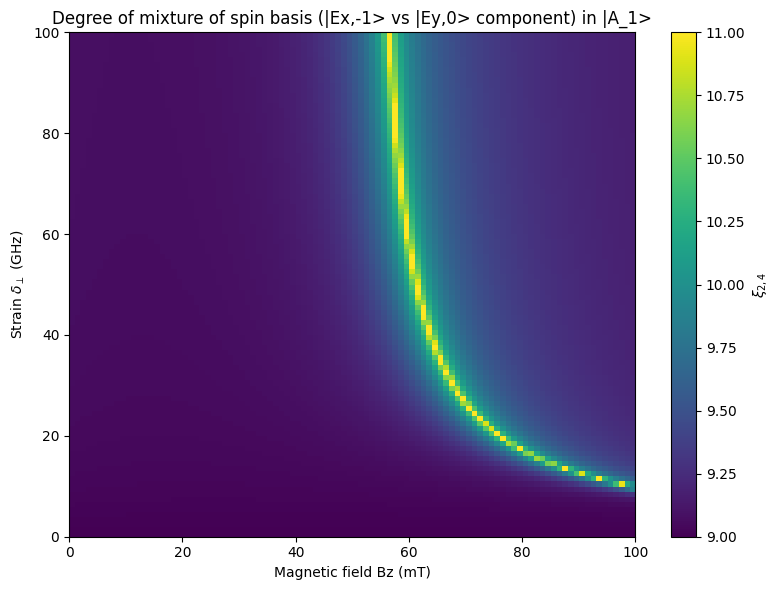

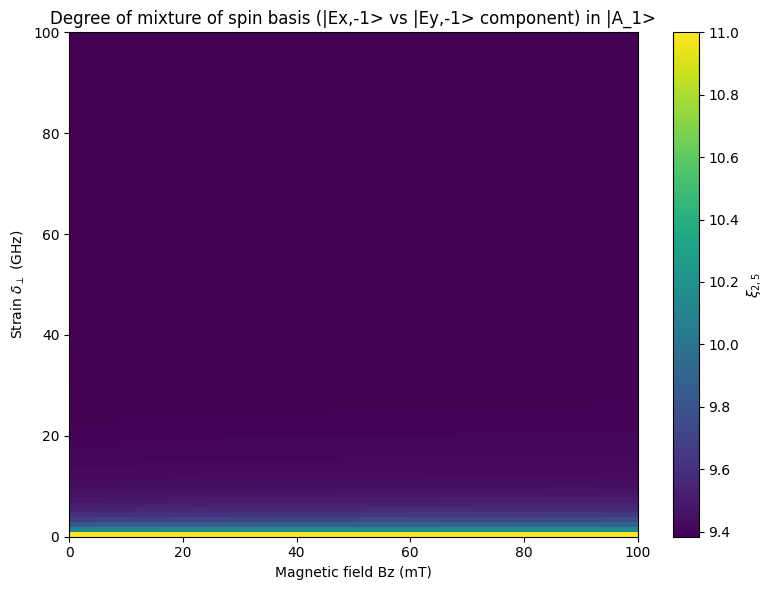

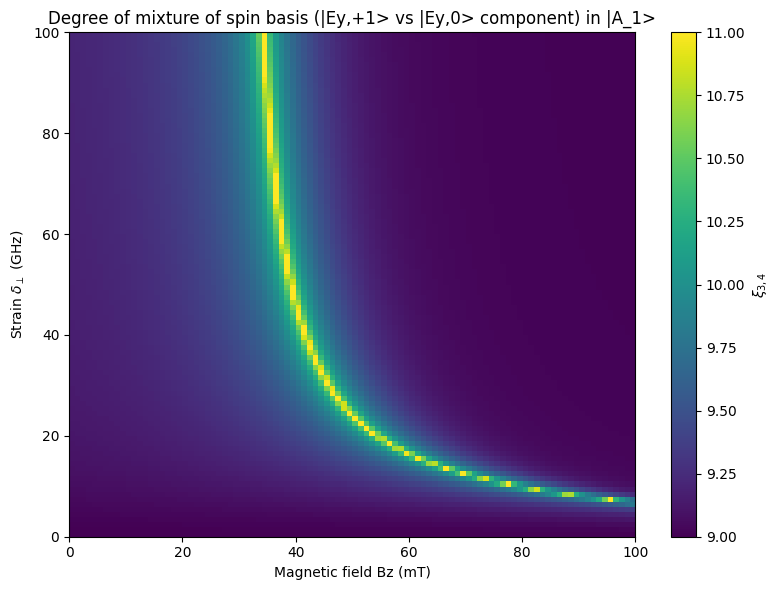

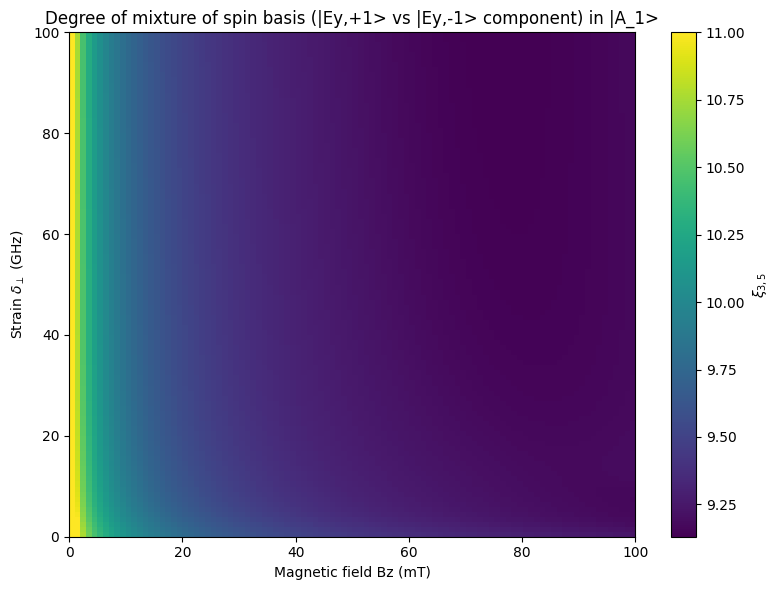

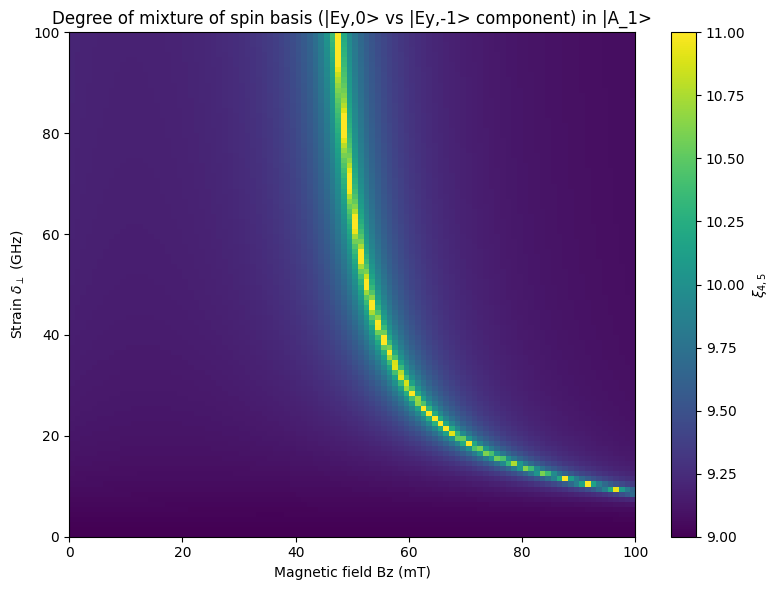

In [33]:

for i in range(0,6):
    for j in range(i,6):
        if i != j:
            making_colormap_spin_basis(s, i, j)

In [38]:

# mapping function 
def map_spin_fun(Number_Es):
    # Meshgrid parameters
    E = [0, 0, 0]
    strain_perp_values = np.linspace(0, 100e9, 100)
    Bz_values = np.linspace(0, 1000e-4, 100)

    # Allocate result matrix for score 
    score_map = np.zeros((len(strain_perp_values), len(Bz_values)))

    # Evaluate 1/diff over parameter space
    for k, strain_perp in enumerate(strain_perp_values):
        deltax = deltay = strain_perp / np.sqrt(2) / des_perp
        strain = [deltax, deltay, 0]

        for w, Bz in enumerate(Bz_values):
            B = [0, 0, Bz]
            H_tot = H_es + V_es(E, B, strain)

            amp_list = Decomposition(H_tot)[Number_Es]  

            score = 0.0

            for i in range(6):

                for j in range(i+1,6):
                    diff = Xi(amp_list, i, j)           # Xi between 1st and 3rd components

                    # To avoid dividing by very small numbers, clamp diff
                    if diff < 1e-2:
                        diff = 1e-2
                        

                    score += (1e9/diff)

                    score_map[k, w] = math.log10(score)   # Normalized unit: 1/nanosecond or similar

    plt.figure(figsize=(8, 6))
    plt.imshow(score_map, extent=[   Bz_values[0]*1e3, Bz_values[-1]*1e3,
        strain_perp_values[0]/1e9, strain_perp_values[-1]/1e9],
            origin='lower', aspect='auto', cmap='viridis')

    # converting spin_number => ES
    E_state = get_key_from_value(Es, Number_Es)
    i_component = get_key_from_value(spin_basis, i)
    j_component = get_key_from_value(spin_basis, j)

    plt.colorbar(label=r'$\sum_{i,j}\xi_{i,j}$')
    plt.xlabel('Magnetic field Bz (mT)')
    plt.ylabel(r'Strain $\delta_{\perp}$ (GHz)')
    plt.title('Mixture of spin basis  in %s' %(E_state))
    plt.tight_layout()


C:\Users\risei\AppData\Local\Temp\ipykernel_19236\1135440583.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = math.log10(score)   # Normalized unit: 1/nanosecond or similar


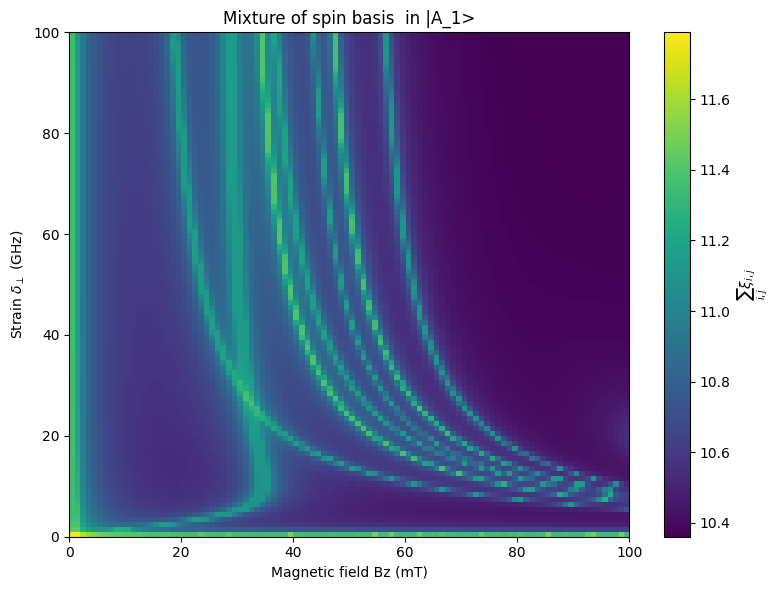

In [39]:
map_spin_fun(1)

C:\Users\risei\AppData\Local\Temp\ipykernel_19236\1135440583.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_map[k, w] = math.log10(score)   # Normalized unit: 1/nanosecond or similar


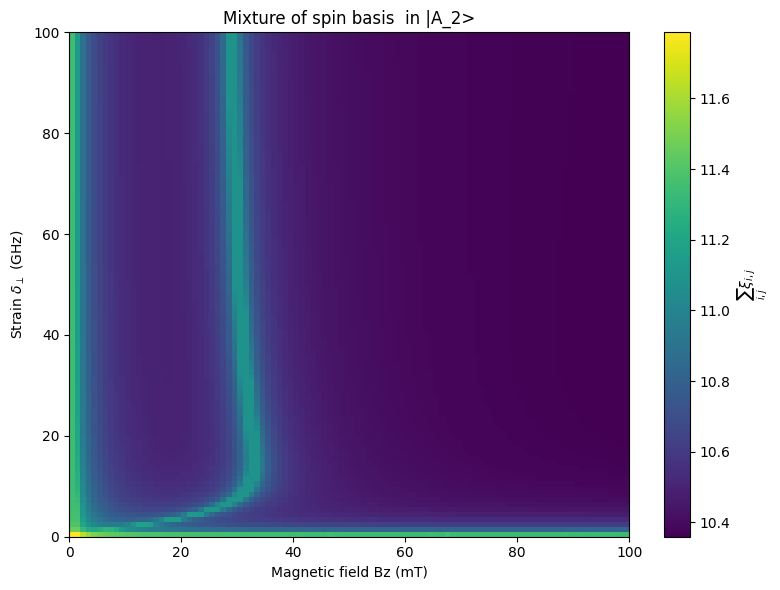

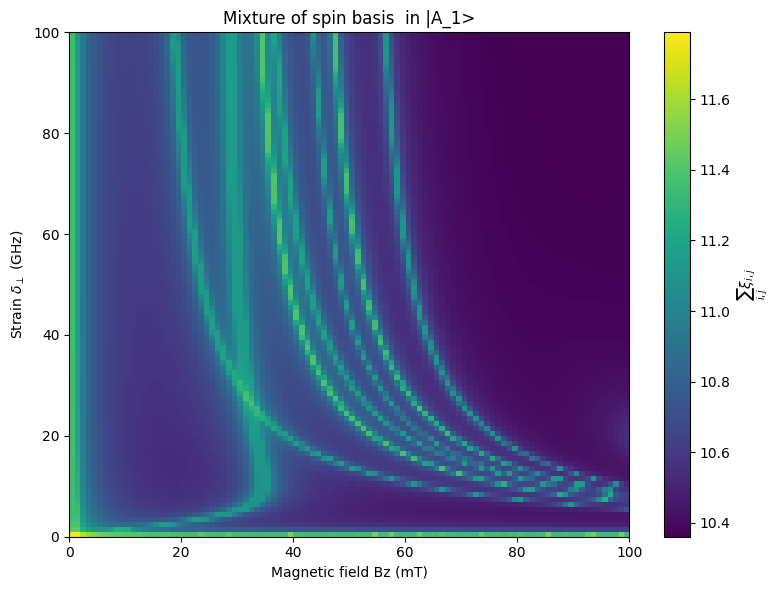

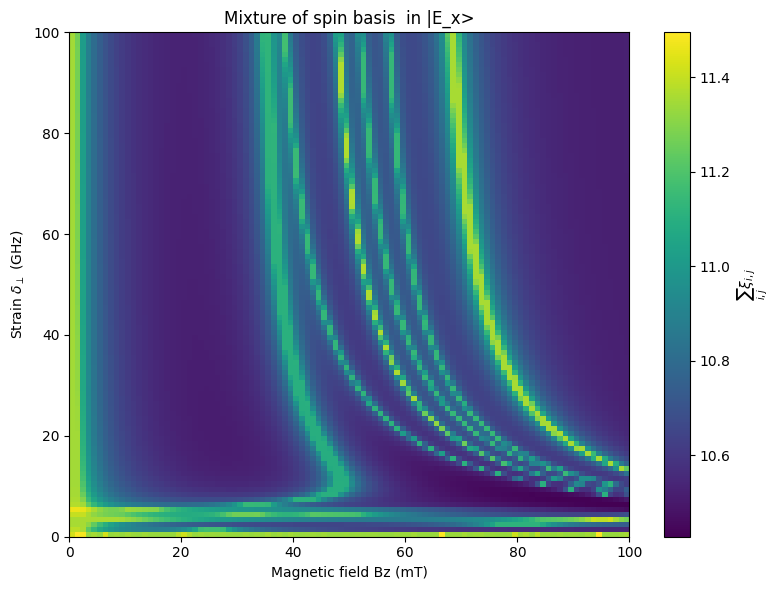

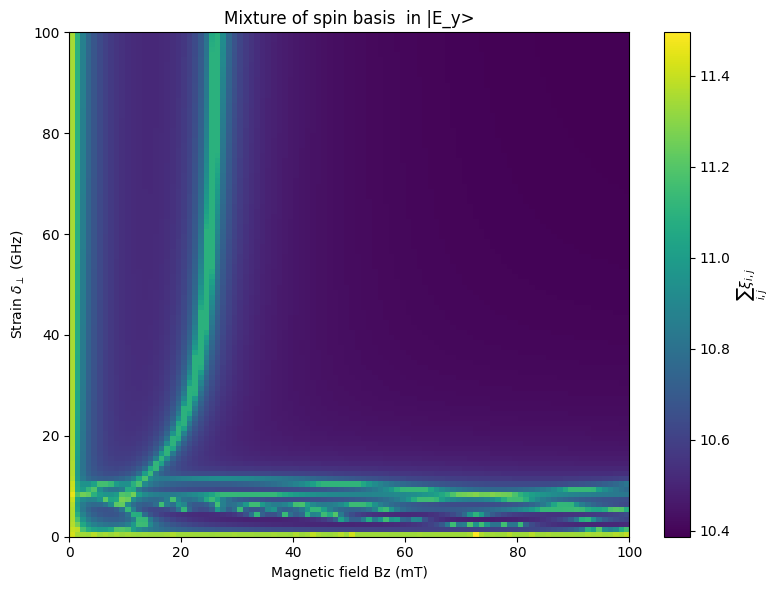

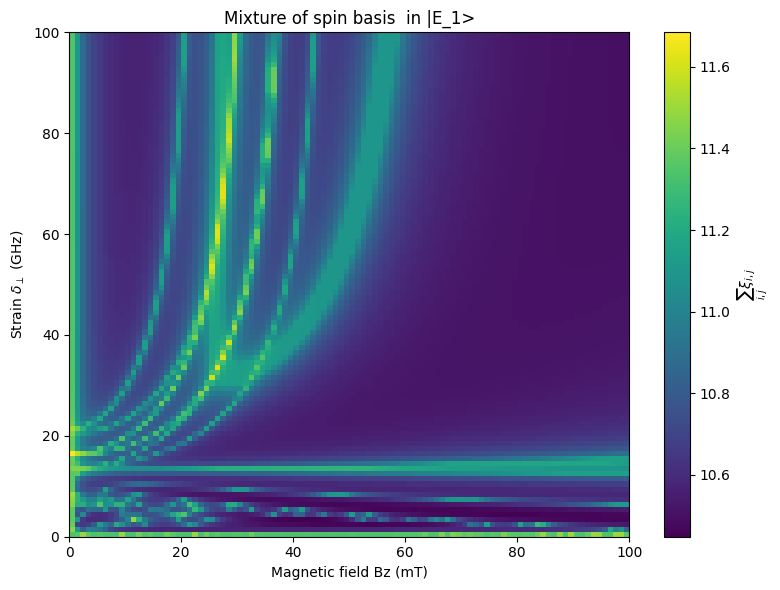

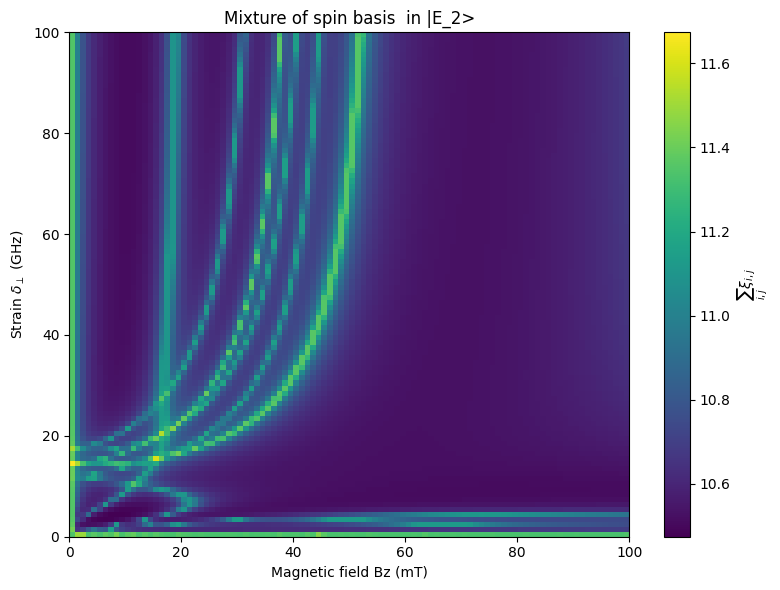

In [40]:
for i in range(6):
    map_spin_fun(i)
